In [16]:
import requests

url = 'https://files.zillowstatic.com/research/public_csvs/zhvi/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv?t=1739632436'
response = requests.get(url)
if response.status_code == 200:
    with open('zillow_home_values_data.csv', 'wb') as file:
        file.write(response.content)
    print("ZHVI dataset downloaded successfully.")

ZHVI dataset downloaded successfully.


In [17]:
import pandas as pd

# Load the dataset
file_path = "zillow_home_values_data.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895 entries, 0 to 894
Columns: 306 entries, RegionID to 2025-01-31
dtypes: float64(301), int64(2), object(3)
memory usage: 2.1+ MB


(None,
    RegionID  SizeRank       RegionName RegionType StateName     2000-01-31  \
 0    102001         0    United States    country       NaN  119729.572640   
 1    394913         1     New York, NY        msa        NY  214911.652349   
 2    753899         2  Los Angeles, CA        msa        CA  218489.647448   
 3    394463         3      Chicago, IL        msa        IL  150432.480390   
 4    394514         4       Dallas, TX        msa        TX  125268.936932   
 
       2000-02-29     2000-03-31     2000-04-30     2000-05-31  ...  \
 0  119940.215341  120201.443305  120761.726012  121406.544234  ...   
 1  215824.905614  216746.617250  218614.361683  220548.475724  ...   
 2  219302.706154  220385.692595  222540.471813  224897.124751  ...   
 3  150571.737044  150836.953795  151496.747161  152290.399220  ...   
 4  125324.732154  125388.874474  125555.445340  125775.064467  ...   
 
       2024-04-30     2024-05-31     2024-06-30     2024-07-31     2024-08-31  \
 0  3501

In [18]:
# Summary statistics for the home values (excluding non-numeric columns)
summary_stats = df.iloc[:, 5:].describe()

# Checking for missing values
missing_values = df.isnull().sum().sum()

# Display the summary statistics and missing values count
summary_stats, missing_values

(          2000-01-31     2000-02-29     2000-03-31     2000-04-30  \
 count     431.000000     432.000000     433.000000     435.000000   
 mean   105958.656088  106137.421622  106285.089128  106956.124245   
 std     46834.790998   46947.421303   47137.263973   47785.076802   
 min     34570.803101   34565.049531   34547.699940   34510.601907   
 25%     74691.301893   74825.420592   75071.375438   75409.535457   
 50%     94101.460590   94627.659943   94602.065976   95007.243258   
 75%    122188.259790  122233.229748  122414.839114  122995.553417   
 max    359885.688957  361740.508462  364534.760117  372101.794291   
 
           2000-05-31     2000-06-30     2000-07-31     2000-08-31  \
 count     437.000000     438.000000     439.000000     440.000000   
 mean   107683.356710  108240.400493  108991.036688  109597.852101   
 std     48384.707398   48995.723661   49699.146141   50427.412993   
 min     34492.930594   34490.210240   34570.925896   34694.315071   
 25%     75779.293

The histogram shows a right-skewed distribution of home values as of January 2025, indicating that:

Most home values are concentrated in the lower range (under $500K).
A few high-value properties drive up the maximum, suggesting strong disparities across metro areas.

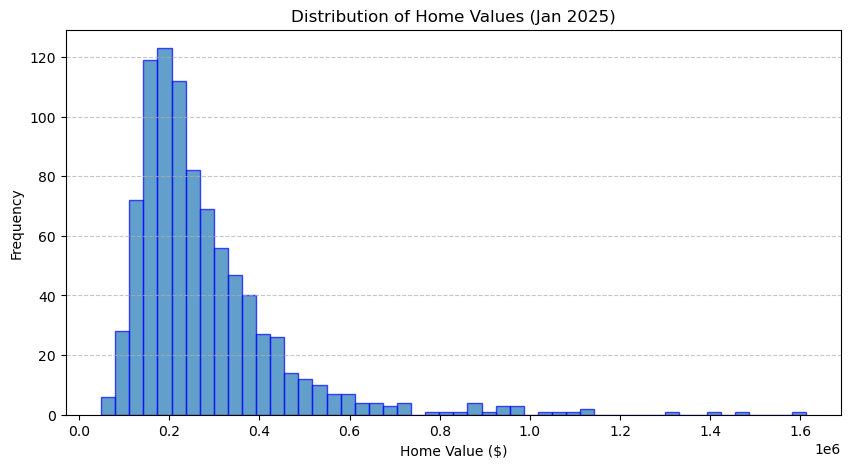

In [19]:
import matplotlib.pyplot as plt

# Plot distribution of latest home values (Jan 2025)
latest_prices = df["2025-01-31"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(latest_prices, bins=50, edgecolor='blue', alpha=0.7)
plt.xlabel("Home Value ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Home Values (Jan 2025)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


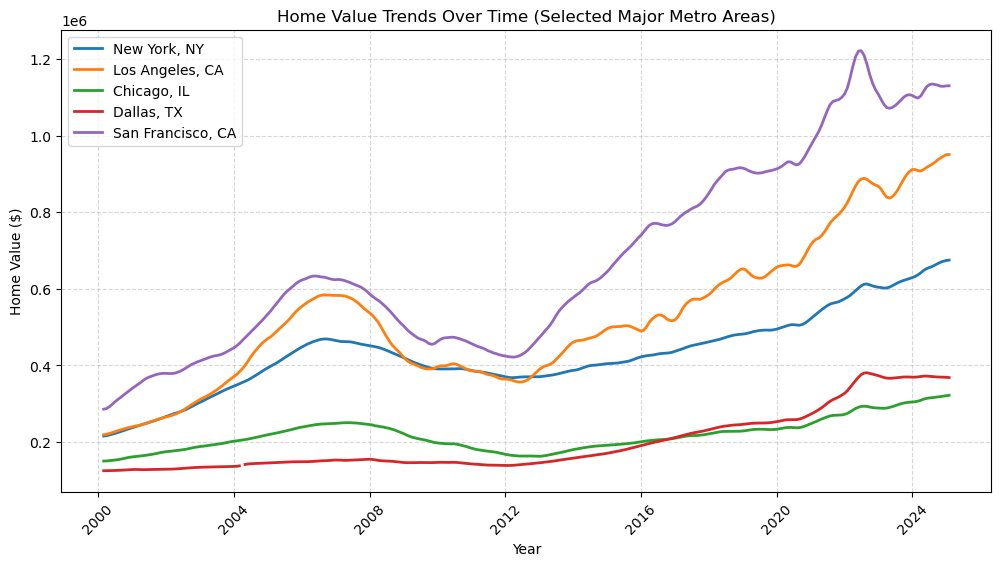

In [20]:
# Selecting major metro areas for trend analysis
selected_metros = ["New York, NY", "Los Angeles, CA", "Chicago, IL", "Dallas, TX", "San Francisco, CA"]

# Filtering data for selected metros
df_selected_metros = df[df["RegionName"].isin(selected_metros)]

# Extracting only the time-series data
df_selected_trend = df_selected_metros.set_index("RegionName").iloc[:, 5:].T

# Converting index to datetime for better visualization
df_selected_trend.index = pd.to_datetime(df_selected_trend.index)

# Plotting home value trends over time
plt.figure(figsize=(12, 6))
for metro in selected_metros:
    plt.plot(df_selected_trend.index, df_selected_trend[metro], label=metro, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.title("Home Value Trends Over Time (Selected Major Metro Areas)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(linestyle="--", alpha=0.5)
plt.show()


/var/folders/cr/d024fnbj3kl4z95bzjt7267h0000gn/T/ipykernel_94658/2407569008.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_statewise.index, y=df_statewise.values, palette="coolwarm")


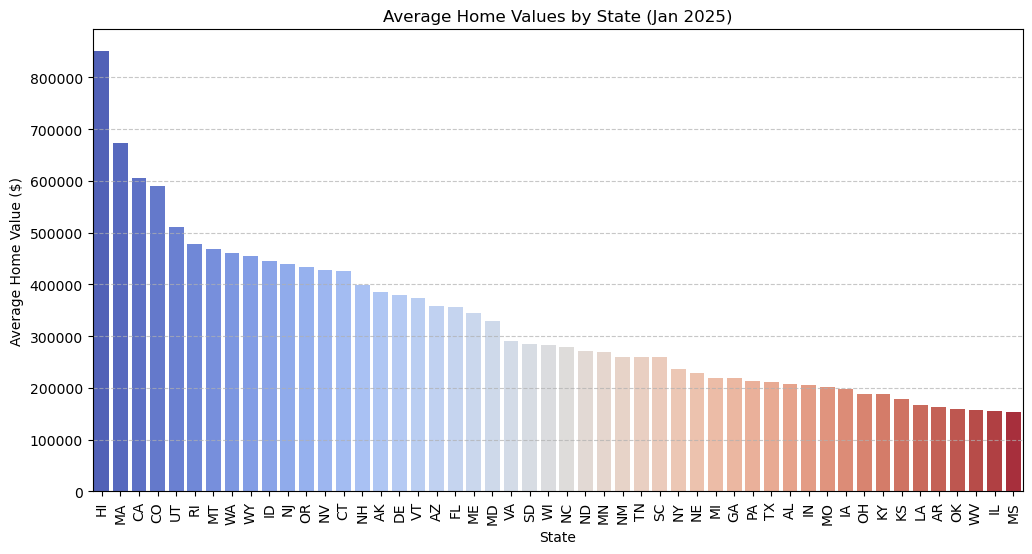

In [8]:
import seaborn as sns

# Extracting the latest home values (Jan 2025) by state
df_statewise = df.groupby("StateName")["2025-01-31"].mean().dropna().sort_values(ascending=False)

# Plotting the heatmap
plt.figure(figsize=(12, 6))
sns.barplot(x=df_statewise.index, y=df_statewise.values, palette="coolwarm")
plt.xlabel("State")
plt.ylabel("Average Home Value ($)")
plt.title("Average Home Values by State (Jan 2025)")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



In [10]:

# Checking the first few rows to confirm successful import
# Categorizing home values into High, Mid, and Low based on the latest available data (Jan 2025)
df["HomeValueCategory"] = pd.qcut(df["2025-01-31"], q=[0, 0.33, 0.67, 1.0], labels=["Low", "Mid", "High"])

# Counting the number of regions in each category
category_counts = df["HomeValueCategory"].value_counts()

# Display the category counts
category_counts


HomeValueCategory
Mid     303
Low     296
High    296
Name: count, dtype: int64

/var/folders/cr/d024fnbj3kl4z95bzjt7267h0000gn/T/ipykernel_94658/2969578924.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_category_counts = df.groupby(["StateName", "HomeValueCategory"])["RegionID"].count().unstack()


<Figure size 1400x600 with 0 Axes>

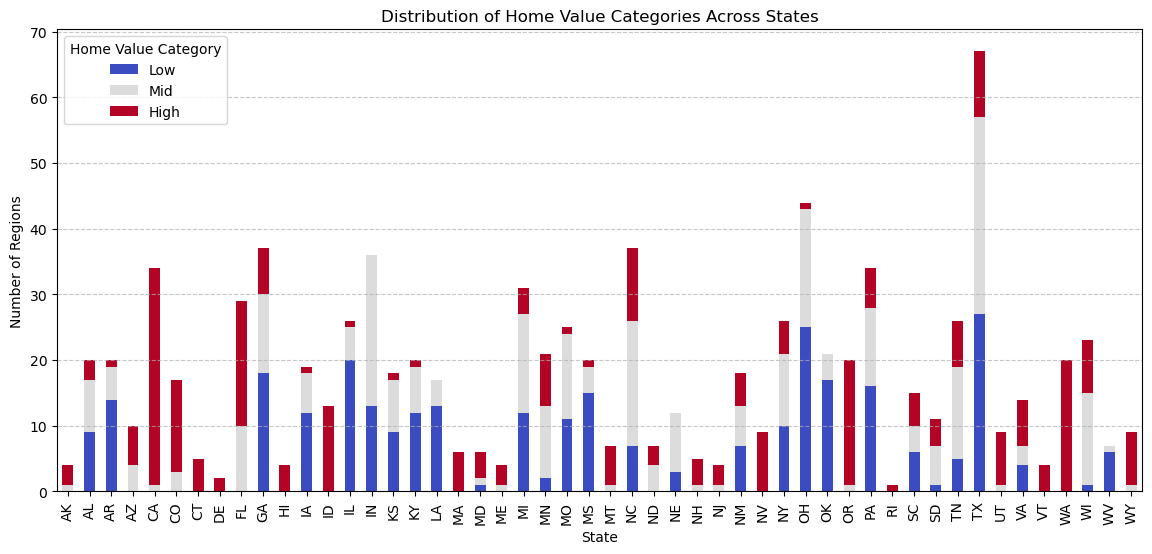

In [12]:
# Grouping by state to see how many regions in each state fall into each category
state_category_counts = df.groupby(["StateName", "HomeValueCategory"])["RegionID"].count().unstack()

# Plotting the distribution of home value categories across states
plt.figure(figsize=(14, 6))
state_category_counts.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(14, 6))

plt.xlabel("State")
plt.ylabel("Number of Regions")
plt.title("Distribution of Home Value Categories Across States")
plt.legend(title="Home Value Category")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



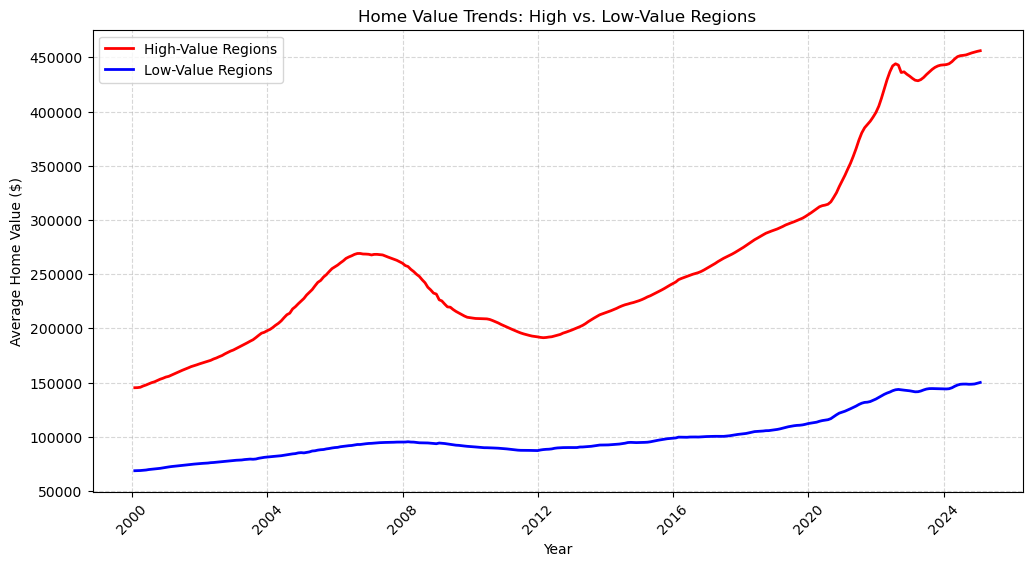

In [13]:
# Extracting time-series data for high and low-value regions
df_high_value = df[df["HomeValueCategory"] == "High"].iloc[:, 5:-1].mean()
df_low_value = df[df["HomeValueCategory"] == "Low"].iloc[:, 5:-1].mean()

# Converting index to datetime format
df_high_value.index = pd.to_datetime(df_high_value.index)
df_low_value.index = pd.to_datetime(df_low_value.index)

# Plotting home value trends for high and low-value regions
plt.figure(figsize=(12, 6))
plt.plot(df_high_value.index, df_high_value, label="High-Value Regions", linewidth=2, color='red')
plt.plot(df_low_value.index, df_low_value, label="Low-Value Regions", linewidth=2, color='blue')

plt.xlabel("Year")
plt.ylabel("Average Home Value ($)")
plt.title("Home Value Trends: High vs. Low-Value Regions")
plt.legend()
plt.xticks(rotation=45)
plt.grid(linestyle="--", alpha=0.5)
plt.show()
